<a href="https://colab.research.google.com/github/adubay96/skills-introduction-to-github/blob/Main-Branch/GWPZ_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Leveraging Geospatial Artificial Intelligence (Geo-AI) for Groundwater Resource Assessment in the Rift Valley Lakes Basins, Ethiopia.

<figure>
<img <img src="https://i.ibb.co/n8gPJTqS/overlay.png"
<figcaption align = "bottom">Thematic overlay </figcaption>
</figure>       

# Table of contents
1. [Introduction]()
2. [Methodology]()
3. [Results]()  
4. [Conclusion]()
5. [Recommendation]()

# 1. Introduction<a name="background"></a>
Gidabo watershed; Originate from northeastern mountain of Soka Sonicha, it finally terminates in Lake Abaya. Estimated length of 120 Km, and contributing source area of 3313 sq km.

**The main objective is to identify groundwater potential zones using geospatial data and Machine learning (Random forest and K-NN) techniques for sustainable management of the resource.**
The location and topography is shown below.
<figure>
<img <img src="https://i.ibb.co/6Jqf9dMH/location.png"
<figcaption align = "center">Location map of Study area </figcaption>
</figure>


#2. Methedology


 (1)  **Nine thematic layers have been selected that indicate area with a high likelihood of groundwater occurence and thier spatial distribution**
  
<figure>
<img <img src="https://i.ibb.co/SwHr7r7Q/table.png"
<figcaption align = "center">Input Thematic Layer </figcaption>
</figure>       



*   By Using Arc-GIS the differnt thematic layers projected to (EPSG: 32637/ WGCS84/UTM Zone 37N) and Resampled to common spatial resolution of (30m) as per suitable for overlaying.

*  BILINEAR method used for downsampling of layers (Rainfall, and soil)
*  MAJORITY resampling techinique to upscale landcover from 10m to 3om to preserve class integrity






(2) **Prepare Spring and non spring data for training and testing** using Arc-GIs


*  prepared Spring location as shapefile with (easting & northing) assign 1 as presence of Spring (collected from Minstry of Wter and Energy)
*  Created non spring /abscence points with consideration of hydrogeological principles, by


1.   Sample size; generate equal number of abscens points to avoid class imbalance (chen etal 2018).
2.   Spatial Autocorrelation; Maintain minimum 500m separation between all points (presence and abscence) to satisfy ML independncy assumption (Falah et al 2020).
3.   Hydrogeological Plausiblity; Absence points should represent areas where springs are possible but absent. not hydrogeologically impossible locations (e.g., impermeable bedrock).









# Steps To Process Machine Learning (Random Forest & K-NN) preparation

Step 1; Load the nine thematic layer and Groundwater training dataset

Groundwater thematic Layer

1.   Lithology          (thematic_1)
2.   Lineament Density  (thematic_2)
3.   Geomorphology      (thematic_3)
4.   Slope              (thematic_4)
5.   Proximity to River (thematic_5)
6.   Drainage Density   (thematic_6)
7.   Landcover          (thematic_7)
8.   Soil Texture       (thematic_8)
9.   Rainfall           (thematic_9)





In [1]:
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# STEP 2: Install Required Libraries
!pip install geopandas rasterio scikit-learn matplotlib shapely fiona


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 637.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 40.4 MB/s eta 0:00:00


In [3]:
# STEP 3: Import Libraries
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.plot import show
from shapely.geometry import Point
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix


In [4]:
# STEP 4: Define Paths
# Update this path to your own directory
data_dir = '/content/drive/MyDrive/Groundwater_Mapping/'

# Raster files (assume .tif files named thematic_1.tif to thematic_9.tif)
raster_paths = [os.path.join(data_dir, f'thematic_{i}.tif') for i in range(1, 10)]

# Spring/non-spring point shapefile (with column: "class" where 1 = spring, 0 = non-spring)
points_path = os.path.join(data_dir, 'Spring_points.shp')


In [5]:
# STEP 5: Load Raster Layers into a Stack
raster_arrays = []
meta = None
reference_shape = None

for path in raster_paths:
    with rasterio.open(path) as src:
        if meta is None:
            meta = src.meta.copy()
            reference_shape = (src.height, src.width)

        # Read the raster, resampling to the reference shape if necessary
        data = src.read(1, out_shape=reference_shape, resampling=rasterio.enums.Resampling.bilinear)
        raster_arrays.append(data)

# Convert to (rows, cols, bands)
raster_stack = np.stack(raster_arrays, axis=-1)
print("Raster stack shape:", raster_stack.shape)

Raster stack shape: (2948, 2322, 9)


In [6]:
# STEP 6: Load Spring/Non-Spring Points
points_gdf = gpd.read_file(points_path)
points_gdf = points_gdf.to_crs(meta['crs'])  # Match CRS


In [7]:
# STEP 7: Extract Raster Values at Point Locations
def extract_raster_values(rasters, points, transform):
    features = []
    labels = []

    for idx, point in points.iterrows():
        row, col = ~transform * (point.geometry.x, point.geometry.y)
        row, col = int(row), int(col)

        try:
            values = rasters[row, col, :]
            if np.any(np.isnan(values)):  # skip if NaN
                continue
            features.append(values)
            labels.append(point['class'])  # assuming column is named 'class'
        except:
            continue

    return np.array(features), np.array(labels)

features, labels = extract_raster_values(raster_stack, points_gdf, meta['transform'])

print("Features shape:", features.shape)


Features shape: (410, 9)


In [8]:
# STEP 8: Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(features, labels)

# Evaluate model
pred = clf.predict(features)
print(confusion_matrix(labels, pred))
print(classification_report(labels, pred))


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


[[187   0]
 [  5 218]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       187
           1       1.00      0.98      0.99       223

    accuracy                           0.99       410
   macro avg       0.99      0.99      0.99       410
weighted avg       0.99      0.99      0.99       410



/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [9]:
# STEP 9: Predict Groundwater Potential Map
rows, cols, bands = raster_stack.shape
flat_pixels = raster_stack.reshape(-1, bands)

# Remove any NaN rows
valid_mask = ~np.isnan(flat_pixels).any(axis=1)
valid_pixels = flat_pixels[valid_mask]

# Predict
predictions = clf.predict(valid_pixels)

# Create final prediction map with NaNs where data is missing
gw_potential_flat = np.full(flat_pixels.shape[0], np.nan)
gw_potential_flat[valid_mask] = predictions

# Reshape to raster
gw_potential_map = gw_potential_flat.reshape(rows, cols)


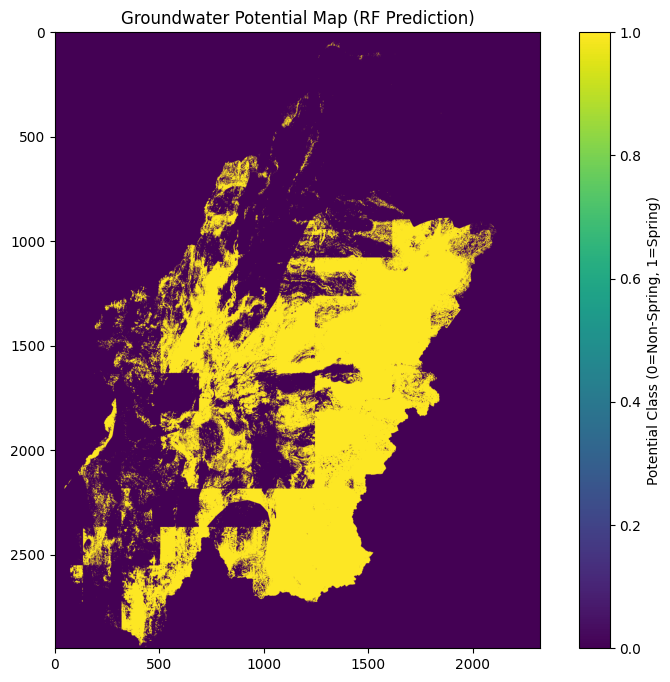

In [10]:
# STEP 10: Visualize the Prediction Map
plt.figure(figsize=(10, 8))
plt.title("Groundwater Potential Map (RF Prediction)")
plt.imshow(gw_potential_map, cmap='viridis')
plt.colorbar(label='Potential Class (0=Non-Spring, 1=Spring)')
plt.show()


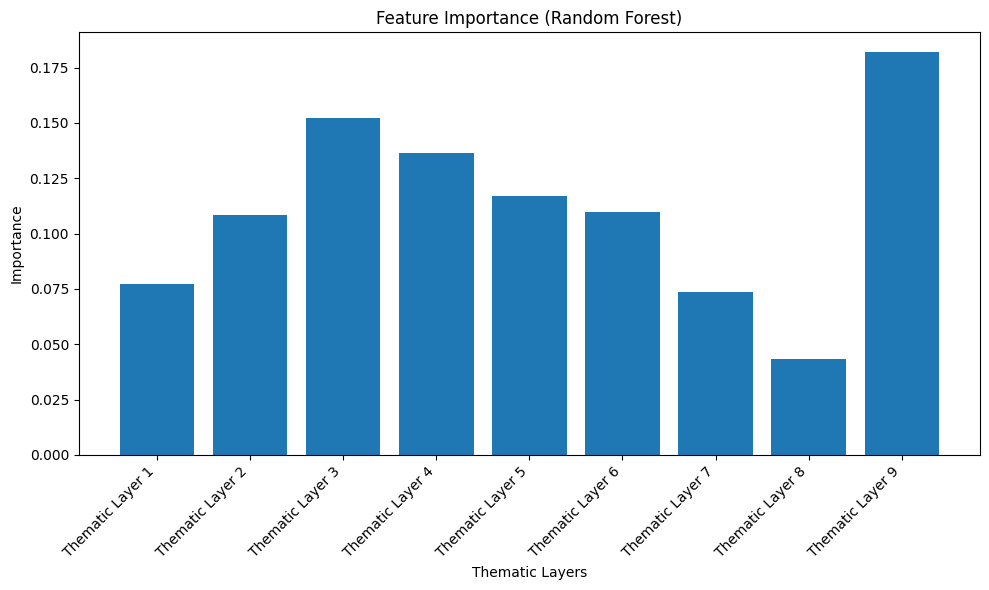

In [11]:
#step 11 Vissualise the importance of features/ thematic layers
import matplotlib.pyplot as plt

importances = clf.feature_importances_
# Use a different variable name for the feature labels to avoid overwriting the data
feature_names = [f'Thematic Layer {i}' for i in range(1, 10)]

plt.figure(figsize=(10, 6))
plt.bar(feature_names, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Thematic Layers")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
#step12 Train K-NN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train K-NN using the original 'features' data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(features, labels)

#evaluate model
pred_knn = knn.predict(features)
print("K-NN Model Evaluation")
print(confusion_matrix(labels, pred_knn))
print(classification_report(labels, pred_knn))

K-NN Model Evaluation
[[132  55]
 [ 44 179]]
              precision    recall  f1-score   support

           0       0.75      0.71      0.73       187
           1       0.76      0.80      0.78       223

    accuracy                           0.76       410
   macro avg       0.76      0.75      0.76       410
weighted avg       0.76      0.76      0.76       410



In [13]:
#Step 13 Predict Groundwater potential
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Remove any NaN rows
valid_mask = ~np.isnan(flat_pixels).any(axis=1)
valid_pixels = flat_pixels[valid_mask]

# predict
predictions = clf.predict(valid_pixels)

# Create final prediction map with NaNs where data is missing
gw_potential_flat = np.full(flat_pixels.shape[0], np.nan)
gw_potential_flat[valid_mask] = predictions

# Reshape to raster
gw_potential_map = gw_potential_flat.reshape(rows, cols)

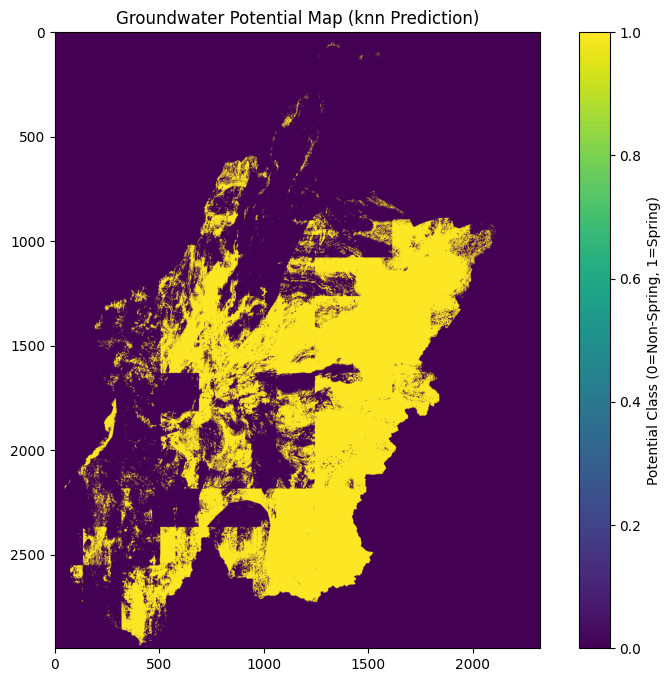

In [14]:
# STEP 14: Visualize the Prediction Map
plt.figure(figsize=(10, 8))
plt.title("Groundwater Potential Map (knn Prediction)")
plt.imshow(gw_potential_map, cmap='viridis')
plt.colorbar(label='Potential Class (0=Non-Spring, 1=Spring)')
plt.show()